In [57]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
import asyncio


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# llm = ChatOpenAI(
#     model="stepfun/step-3.5-flash:free",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [58]:
class llm_state(BaseModel):
    is_correct: bool = Field(..., description = "Code generated is correct or not")
    feedback: str = Field(..., description = "Feedback on the code generated")
    imp_needed: bool = Field(..., description = "Improvement needed or not")

In [59]:
class graph_state(BaseModel):
    question: str = Field(..., description = "Question to write code for")
    code: str = Field(..., description = "Code generated for the question")
    is_correct: bool = Field(..., description = "Code generated is correct or not")
    imp_needed: bool = Field(..., description = "Improvement needed or not")
    feedback: str = Field(..., description = "Feedback on the code generated")
    iterations: int = Field(..., description = "No of tries done to execute correct code")

In [60]:
def coder(state: graph_state) -> graph_state:
    question = state.question
    feedback = state.feedback
    code = state.code
    if len(feedback) > 0:
        code = llm.invoke(f"""You are a helpful code generator. You generated some code for a question and got some feedback.

        Question:

        {question}

        Code:

        {code}

        Feedback:

        {feedback}

        Generate a new corrected code in proper format based on the feedback.
        """)
    else:
        code = llm.invoke(f"""You are a helpful code generator. You have to generate code in proper format for the given question.

        Question:

        {question}

        """)
    state.code = code.content
    state.iterations = state.iterations + 1
    return state

In [61]:
def evaluator(state: graph_state) -> graph_state:
    question = state.question
    code = state.code
    parser = PydanticOutputParser(pydantic_object=llm_state)
    response = llm.invoke(f"""You are a code evaluator. You have been given a question and code written for
    that question. You have to evaluate the code and tell if it is correct or not and also provide feedback 
    for further improvements. Also tell if you think the code can be improved further. And if it can
    be improved further, reply in 'imp_needed' field as True.

    Question:
    {question}

    Code:
    {code}

    {parser.get_format_instructions()}
    """)
    parsed = parser.parse(response.content)
    state.feedback = parsed.feedback
    state.is_correct = parsed.is_correct
    state.imp_needed = parsed.imp_needed
    return state

In [38]:
graph_obj = graph_state(
    question = 'Write code to return a lidt of prime numbers till 1000.',
    code = '',
    feedback = '',
    is_correct = False,
    imp_needed = False,
    iterations = 0
)

In [50]:
resp1 = coder(graph_obj)

In [51]:
show_markdown(resp1.code)

Python – Optimised Sieve of Eratosthenes (list + generator)                                                        

                                                                                                                   
 from __future__ import annotations                                                                                
                                                                                                                   
 def _validate_limit(limit: int) -> None:                                                                          
     """                                                                                                           
     Validate the `limit` argument.                                                                                
                                                                                                                   
     * Must be an integer.                                                                                         
     * Must be non‑negative (a negative limit makes no sense for a range of numbers).                              
                                                                                                                   
     Raises                                                                                                        
     ------                                                                                                        
     TypeError                                                                                                     
         If ``limit`` is not an ``int``.                                                                           
     ValueError                                                                                                    
         If ``limit`` is negative.                                                                                 
     """                                                                                                           
     if not isinstance(limit, int):                                                                                
         raise TypeError(f"limit must be an int, got {type(limit)!r}")                                             
     if limit < 0:                                                                                                 
         raise ValueError("limit must be non‑negative")                                                            
                                                                                                                   
                                                                                                                   
 def primes_upto(limit: int = 1000) -> list[int]:                                                                  
     """                                                                                                           
     Return a **list** of all prime numbers ≤ ``limit`` (inclusive).                                               
                                                                                                                   
     The implementation uses a ``bytearray`` instead of a list of booleans,                                        
     which reduces the memory footprint from 1 byte per entry to a single                                          
     byte for every 8 numbers (the underlying CPython representation of a                                          
     ``bytearray``).                                                                                               
                                                                                                                   
     Parameters                                                                                                    
     ----------                                        

In [52]:
resp2 = evaluator(resp1)

In [53]:
show(resp2)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ graph_state(                                                                                                    │
│     question='Write code to return a lidt of prime numbers till 1000.',                                         │
│     code='**Python – Optimised Sieve of Eratosthenes (list\u202f+\u202fgenerator)**  \n\n```python\nfrom        │
│ __future__ import annotations\n\ndef _validate_limit(limit: int) -> None:\n    """\n    Validate the `limit`    │
│ argument.\n\n    * Must be an integer.\n    * Must be non‑negative (a negative limit makes no sense for a range │
│ of numbers).\n\n    Raises\n    ------\n    TypeError\n        If ``limit`` is not an ``int``.\n                │
│ ValueError\n        If ``limit`` is negative.\n    """\n    if not isinstance(limit, int):\n        raise       │
│ TypeError(f"limit must be an int, got {type(limit)!r}")\n    if limit < 0:\n        raise ValueError("limit     │
│ must be non‑negative")\n\n\ndef primes_upto(limit: int = 1000) -> list[int]:\n    """\n    Return a **list** of │
│ all prime numbers ≤ ``limit`` (inclusive).\n\n    The implementation uses a ``bytearray`` instead of a list of  │
│ booleans,\n    which reduces the memory footprint from 1\u202fbyte per entry to a single\n    byte for every 8  │
│ numbers (the underlying CPython representation of a\n    ``bytearray``).\n\n    Parameters\n    ----------\n    │
│ limit : int, optional\n        Upper bound of the search (default 1000).\n\n    Returns\n    -------\n          │
│ list[int]\n        All prime numbers up to ``limit``.\n    """\n    _validate_limit(limit)\n\n    if limit <    │
│ 2:\n        return []\n\n    # 1 means “prime”, 0 means “composite”.\n    sieve = bytearray(b"\\x01") * (limit  │
│ + 1)\n    sieve[0] = sieve[1] = 0                     # 0 and 1 are not prime\n\n    # Only need to cross‑out   │
│ multiples up to √limit.\n    for p in range(2, int(limit ** 0.5) + 1):\n        if sieve[p]:\n            #     │
│ start at p*p to avoid redundant work\n            start = p * p\n            step = p\n                         │
│ sieve[start:limit + 1:step] = b"\\x00" * ((limit - start) // step + 1)\n\n    # Convert the indices that stayed │
│ 1 into a list of integers.\n    return [i for i, is_prime in enumerate(sieve) if is_prime]\n\n\ndef             │
│ prime_generator(limit: int = 1000):\n    """\n    Yield prime numbers ≤ ``limit`` one‑by‑one.\n\n    A          │
│ generator is useful when the consumer does not need the whole list\n    in memory (e.g., when ``limit`` is very │
│ large).\n\n    Parameters\n    ----------\n    limit : int, optional\n        Upper bound of the search         │
│ (default 1000).\n\n    Yields\n    ------\n    int\n        The next prime number.\n    """\n                   │
│ _validate_limit(limit)\n\n    if limit < 2:\n        return  # nothing to yield\n\n    sieve =                  │
│ bytearray(b"\\x01") * (limit + 1)\n    sieve[0] = sieve[1] = 0\n\n    for p in range(2, int(limit ** 0.5) +     │
│ 1):\n        if sieve[p]:\n            start = p * p\n            step = p\n            sieve[start:limit +     │
│ 1:step] = b"\\x00" * ((limit - start) // step + 1)\n\n    for i, is_prime in enumerate(sieve):\n        if      │
│ is_prime:\n            yield i\n\n\n# ----------------------------------------------------------------------\n# │
│ Example usage\n# ----------------------------------------------------------------------\nif __name__ ==         │
│ "__main__":\n    # List version\n    primes = primes_upto(1000)\n    print("Primes ≤ 1000 (list):")\n           │
│ print(primes)\n\n    # Generator version – prints the same numbers but lazily\n    print("\\nPrimes ≤ 1000      │
│ (generator):")\n    for p in prime_generator(1000):\n        print(p, end=" ")\n    print()\n```\n\n###         │
│ Highlights of the improvements\n1. **Memory‑efficient s

In [62]:
def router(state: graph_state) -> graph_state:
    is_correct = state.is_correct
    imp_needed = state.imp_needed
    iterations = state.iterations
    if iterations == 3:
        return 'end'
    elif not is_correct or imp_needed:
        return 'coder'
    else:
        return 'end'

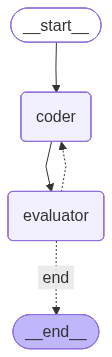

In [63]:
graph = StateGraph(graph_state)

graph.add_node('coder', coder)
graph.add_node('evaluator', evaluator)

graph.add_edge(START, 'coder')
graph.add_edge('coder', 'evaluator')
graph.add_conditional_edges('evaluator', router, {
    'coder': 'coder', 'end': END
})

coder_graph = graph.compile()

from IPython.display import Image, display
Image(coder_graph.get_graph().draw_mermaid_png())

In [71]:
graph_obj = graph_state(
    question = 'Write code to return a lidt of prime numbers till 1000.',
    code = '',
    feedback = '',
    is_correct = False,
    imp_needed = False,
    iterations = 0
)

In [73]:
for chunk in coder_graph.stream(
    graph_obj,
    stream_mode="updates"
):
    print(chunk)

{
    'coder': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**Python – Generate all prime numbers up to\u202f1000**\n\n```python\ndef primes_upto(limit: int =
1000) -> list[int]:\n    """\n    Return a list of all prime numbers <= `limit` using the Sieve of 
Eratosthenes.\n\n    Parameters\n    ----------\n    limit : int, optional\n        Upper bound (inclusive) for the
primes. Default is 1000.\n\n    Returns\n    -------\n    list[int]\n        Sorted list of prime numbers not 
greater than `limit`.\n    """\n    if limit < 2:\n        return []\n\n    # Initially assume every number is 
prime (True), then eliminate composites.\n    is_prime = [True] * (limit + 1)\n    is_prime[0] = is_prime[1] = 
False   # 0 and 1 are not prime\n\n    # Only need to check divisors up to sqrt(limit)\n    for p in range(2, 
int(limit ** 0.5) + 1):\n        if is_prime[p]:\n            # Mark all multiples of p (starting at p*p) as 
non‑prime\n            for multiple in range(p * p, limit + 1, p):\n                is_prime[multiple] = False\n\n 
# Collect the numbers that remain marked as prime\n    return [num for num, prime in enumerate(is_prime) if 
prime]\n\n\nif __name__ == "__main__":\n    # Example usage: print all primes up to 1000\n    prime_list = 
primes_upto(1000)\n    print(prime_list)\n    print(f"Count: {len(prime_list)}")\n```\n\n**Explanation**\n\n1. 
**Sieve of Eratosthenes** – Efficiently eliminates composite numbers by iteratively marking multiples of each 
discovered prime.\n2. The loop runs only up to `√limit` because any composite number larger than that will already 
have a smaller factor that was processed.\n3. After sieving, a list comprehension gathers all indices still marked 
`True` (the prime numbers).\n\nRunning the script prints the complete list of primes ≤\u202f1000 and shows that 
there are **168** such primes.',
        'is_correct': False,
        'imp_needed': False,
        'feedback': '',
        'iterations': 1
    }
}

{
    'evaluator': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**Python – Generate all prime numbers up to\u202f1000**\n\n```python\ndef primes_upto(limit: int =
1000) -> list[int]:\n    """\n    Return a list of all prime numbers <= `limit` using the Sieve of 
Eratosthenes.\n\n    Parameters\n    ----------\n    limit : int, optional\n        Upper bound (inclusive) for the
primes. Default is 1000.\n\n    Returns\n    -------\n    list[int]\n        Sorted list of prime numbers not 
greater than `limit`.\n    """\n    if limit < 2:\n        return []\n\n    # Initially assume every number is 
prime (True), then eliminate composites.\n    is_prime = [True] * (limit + 1)\n    is_prime[0] = is_prime[1] = 
False   # 0 and 1 are not prime\n\n    # Only need to check divisors up to sqrt(limit)\n    for p in range(2, 
int(limit ** 0.5) + 1):\n        if is_prime[p]:\n            # Mark all multiples of p (starting at p*p) as 
non‑prime\n            for multiple in range(p * p, limit + 1, p):\n                is_prime[multiple] = False\n\n 
# Collect the numbers that remain marked as prime\n    return [num for num, prime in enumerate(is_prime) if 
prime]\n\n\nif __name__ == "__main__":\n    # Example usage: print all primes up to 1000\n    prime_list = 
primes_upto(1000)\n    print(prime_list)\n    print(f"Count: {len(prime_list)}")\n```\n\n**Explanation**\n\n1. 
**Sieve of Eratosthenes** – Efficiently eliminates composite numbers by iteratively marking multiples of each 
discovered prime.\n2. The loop runs only up to `√limit` because any composite number larger than that will already 
have a smaller factor that was processed.\n3. After sieving, a list comprehension gathers all indices still marked 
`True` (the prime numbers).\n\nRunning the script prints the complete list of primes ≤\u202f1000 and shows that 
there are **168** such primes.',
        'is_correct': True,
        'imp_needed': True,
        'feedback': 'The implementation correctly returns all prime numbers up to the specified limit (default 
1000) using the Sieve of Eratosthenes. It handles the edge case where limit < 2, marks composites efficiently, and 
returns the primes in a list. The code is clear, well‑documented, and works as intended. Minor improvements could 
be made, such as adding input validation for non‑integer or negative limits, using a `bytearray` for the sieve to 
save memory, or offering an option to yield a generator for very large limits, but these are not required for 
correctness.',
        'iterations': 1
    }
}

{
    'coder': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**Python – Prime numbers up to\u202f1000 (with validation & optional generator)**  
\n\n```python\n#!/usr/bin/env python3\n"""\nPrime number utilities.\n\nThe main entry point is :func:`primes_upto`,
which returns all prime numbers\n≤\u202f``limit``.  The function performs basic input validation, uses a 
compact\n``bytearray`` for the sieve (less memory than a list of booleans) and can\noptionally return a generator 
instead of a list – handy when the limit is\nlarge.\n\nTypical usage\n-------------\n\n>>> primes = 
primes_upto(1000)          # → list[int]\n>>> list(primes_upto(30, as_generator=True))\n[2, 3, 5, 7, 11, 13, 17, 
19, 23, 29]\n"""\n\nfrom __future__ import annotations\n\nfrom math import isqrt\nfrom typing import Generator, 
Iterable, List, Union\n\n\ndef _validate_limit(limit: int) -> None:\n    """Validate the ``limit`` argument.\n\n   
Parameters\n    ----------\n    limit : int\n        Upper bound for prime generation.\n\n    Raises\n    ------\n 
TypeError\n        If ``limit`` is not an integer.\n    ValueError\n        If ``limit`` is negative.\n    """\n   
if not isinstance(limit, int):\n        raise TypeError(f"limit must be an integer, got {type(limit)!r}")\n    if 
limit < 0:\n        raise ValueError("limit must be non‑negative")\n\n\ndef _sieve(limit: int) -> bytearray:\n    
"""Create a sieve of Eratosthenes using a ``bytearray``.\n\n    The ``bytearray`` stores 1 for “potentially prime” 
and 0 for “composite”.\n    """\n    # By definition 0 and 1 are not prime.\n    sieve = bytearray(b"\\x01") * 
(limit + 1)\n    if limit >= 0:\n        sieve[0] = 0\n    if limit >= 1:\n        sieve[1] = 0\n\n    # Only need 
to cross‑out multiples of primes ≤ √limit.\n    for p in range(2, isqrt(limit) + 1):\n        if sieve[p]:\n       
# Start at p*p (all smaller multiples have been crossed out already)\n            start = p * p\n            
sieve[start : limit + 1 : p] = b"\\x00" * ((limit - start) // p + 1)\n    return sieve\n\n\ndef primes_upto(limit: 
int = 1000, *, as_generator: bool = False) -> Union[List[int], Generator[int, None, None]]:\n    """\n    Return 
all prime numbers ≤ ``limit``.\n\n    Parameters\n    ----------\n    limit : int, optional\n        Upper bound 
(inclusive) for the primes.  Default is 1000.\n    as_generator : bool, optional\n        If *True*, a generator 
yielding primes one‑by‑one is returned.\n        If *False* (default), a list of all primes is returned.\n\n    
Returns\n    -------\n    list[int] | generator[int]\n        List of primes or a generator yielding the primes, 
depending on\n        ``as_generator``.\n\n    Raises\n    ------\n    TypeError, ValueError\n        Propagated 
from :func:`_validate_limit` for invalid inputs.\n    """\n    _validate_limit(limit)\n\n    if limit < 2:\n       
return (i for i in []) if as_generator else []\n\n    sieve = _sieve(limit)\n\n    if as_generator:\n        # Lazy
iteration – useful for large limits.\n        return (num for num, is_prime in enumerate(sieve) if is_prime)\n    
else:\n        # Materialise the whole list.\n        return [num for num, is_prime in enumerate(sieve) if 
is_prime]\n\n\n# ----------------------------------------------------------------------\n# Demonstration / simple 
self‑test\n# ----------------------------------------------------------------------\nif __name__ == "__main__":\n  
# 1️⃣ List version (default)\n    prime_list = primes_upto(1000)\n    print(f"Primes ≤\u202f1000 ({len(prime_list)}
total):")\n    print(prime_list)\n\n    # 2️⃣ Generator version – handy for large limits, e.g. 10\u202f000\n    
print("\\nFirst 20 primes ≤\u202f10\u202f000 (using generator):")\n    for i, p in enumerate(primes_upto(10_000, 
as_generator=True)):\n        if i >= 20:\n            break\n        print(p, end=" ")\n    print()\n```\n\n### 
What changed?\n\n| Area | Improvement |\n|------

{
    'evaluator': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**Python – Prime numbers up to\u202f1000 (with validation & optional generator)**  
\n\n```python\n#!/usr/bin/env python3\n"""\nPrime number utilities.\n\nThe main entry point is :func:`primes_upto`,
which returns all prime numbers\n≤\u202f``limit``.  The function performs basic input validation, uses a 
compact\n``bytearray`` for the sieve (less memory than a list of booleans) and can\noptionally return a generator 
instead of a list – handy when the limit is\nlarge.\n\nTypical usage\n-------------\n\n>>> primes = 
primes_upto(1000)          # → list[int]\n>>> list(primes_upto(30, as_generator=True))\n[2, 3, 5, 7, 11, 13, 17, 
19, 23, 29]\n"""\n\nfrom __future__ import annotations\n\nfrom math import isqrt\nfrom typing import Generator, 
Iterable, List, Union\n\n\ndef _validate_limit(limit: int) -> None:\n    """Validate the ``limit`` argument.\n\n   
Parameters\n    ----------\n    limit : int\n        Upper bound for prime generation.\n\n    Raises\n    ------\n 
TypeError\n        If ``limit`` is not an integer.\n    ValueError\n        If ``limit`` is negative.\n    """\n   
if not isinstance(limit, int):\n        raise TypeError(f"limit must be an integer, got {type(limit)!r}")\n    if 
limit < 0:\n        raise ValueError("limit must be non‑negative")\n\n\ndef _sieve(limit: int) -> bytearray:\n    
"""Create a sieve of Eratosthenes using a ``bytearray``.\n\n    The ``bytearray`` stores 1 for “potentially prime” 
and 0 for “composite”.\n    """\n    # By definition 0 and 1 are not prime.\n    sieve = bytearray(b"\\x01") * 
(limit + 1)\n    if limit >= 0:\n        sieve[0] = 0\n    if limit >= 1:\n        sieve[1] = 0\n\n    # Only need 
to cross‑out multiples of primes ≤ √limit.\n    for p in range(2, isqrt(limit) + 1):\n        if sieve[p]:\n       
# Start at p*p (all smaller multiples have been crossed out already)\n            start = p * p\n            
sieve[start : limit + 1 : p] = b"\\x00" * ((limit - start) // p + 1)\n    return sieve\n\n\ndef primes_upto(limit: 
int = 1000, *, as_generator: bool = False) -> Union[List[int], Generator[int, None, None]]:\n    """\n    Return 
all prime numbers ≤ ``limit``.\n\n    Parameters\n    ----------\n    limit : int, optional\n        Upper bound 
(inclusive) for the primes.  Default is 1000.\n    as_generator : bool, optional\n        If *True*, a generator 
yielding primes one‑by‑one is returned.\n        If *False* (default), a list of all primes is returned.\n\n    
Returns\n    -------\n    list[int] | generator[int]\n        List of primes or a generator yielding the primes, 
depending on\n        ``as_generator``.\n\n    Raises\n    ------\n    TypeError, ValueError\n        Propagated 
from :func:`_validate_limit` for invalid inputs.\n    """\n    _validate_limit(limit)\n\n    if limit < 2:\n       
return (i for i in []) if as_generator else []\n\n    sieve = _sieve(limit)\n\n    if as_generator:\n        # Lazy
iteration – useful for large limits.\n        return (num for num, is_prime in enumerate(sieve) if is_prime)\n    
else:\n        # Materialise the whole list.\n        return [num for num, is_prime in enumerate(sieve) if 
is_prime]\n\n\n# ----------------------------------------------------------------------\n# Demonstration / simple 
self‑test\n# ----------------------------------------------------------------------\nif __name__ == "__main__":\n  
# 1️⃣ List version (default)\n    prime_list = primes_upto(1000)\n    print(f"Primes ≤\u202f1000 ({len(prime_list)}
total):")\n    print(prime_list)\n\n    # 2️⃣ Generator version – handy for large limits, e.g. 10\u202f000\n    
print("\\nFirst 20 primes ≤\u202f10\u202f000 (using generator):")\n    for i, p in enumerate(primes_upto(10_000, 
as_generator=True)):\n        if i >= 20:\n            break\n        print(p, end=" ")\n    print()\n```\n\n### 
What changed?\n\n| Area | Improvement |\n|--

{
    'coder': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**prime_upto_1000.py**\n\n```python\n#!/usr/bin/env python3\n"""\nReturn the list of all prime 
numbers ≤\u202f1000.\n\nThe implementation uses a straightforward Sieve of Eratosthenes with a\nplain list of 
booleans – more than enough for the tiny limit of 1000.\nThe module also contains a tiny self‑test that can be run 
with\n`python -m unittest prime_upto_1000.py`.\n"""\n\nfrom math import isqrt\nfrom typing import List\n\n\ndef 
primes_upto_1000() -> List[int]:\n    """Return a list with the 168 prime numbers ≤\u202f1000.\n\n    Returns\n    
-------\n    List[int]\n        All prime numbers from 2 up to and including 1000.\n    """\n    limit = 1000\n\n  
# `True` means “still possibly prime”.\n    sieve: List[bool] = [True] * (limit + 1)\n    sieve[0] = sieve[1] = 
False  # 0 and 1 are not prime\n\n    # Cross out multiples of each prime ≤ √limit.\n    for p in range(2, 
isqrt(limit) + 1):\n        if sieve[p]:\n            for multiple in range(p * p, limit + 1, p):\n                
sieve[multiple] = False\n\n    # Collect the indices that remained `True`.\n    return [num for num, is_prime in 
enumerate(sieve) if is_prime]\n\n\n# ----------------------------------------------------------------------\n# 
Simple sanity check (executed when the module is run directly)\n# 
----------------------------------------------------------------------\nif __name__ == "__main__":\n    primes = 
primes_upto_1000()\n    print(f"Found {len(primes)} primes ≤\u202f1000:")\n    print(primes)\n\n\n# 
----------------------------------------------------------------------\n# Unit test\n# 
----------------------------------------------------------------------\nimport unittest\n\n\nclass 
TestPrimesUpto1000(unittest.TestCase):\n    def test_length(self):\n        """There must be exactly 168 primes 
≤\u202f1000."""\n        self.assertEqual(len(primes_upto_1000()), 168)\n\n    def test_first_and_last(self):\n    
"""Check the first and last primes in the list."""\n        primes = primes_upto_1000()\n        
self.assertEqual(primes[0], 2)          # first prime\n        self.assertEqual(primes[-1], 997)       # largest 
prime ≤\u202f1000\n\n    def test_known_prime(self):\n        """A few known primes should be present."""\n        
primes = set(primes_upto_1000())\n        for known in (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 997):\n            
self.assertIn(known, primes)\n\n    def test_non_prime(self):\n        """A few known composites must be 
absent."""\n        primes = set(primes_upto_1000())\n        for composite in (0, 1, 4, 6, 8, 9, 10, 100, 999):\n 
self.assertNotIn(composite, primes)\n\n\nif __name__ == "__main__":\n    # Run the unit tests when the file is 
executed as a script.\n    unittest.main()\n```\n\n### What was changed?\n\n| Aspect | Revised version 
|\n|--------|-----------------|\n| **API** | Only a single function `primes_upto_1000()` – no `limit` argument, no 
generator flag, no validation. |\n| **Data structure** | Simple `list[bool]` is used for the sieve, which is easier
to read and perfectly fine for the tiny bound of 1000. |\n| **Complexity** | The code now contains only the core 
sieve logic and a clear return‑statement. |\n| **Testing** | A small `unittest` suite validates the exact number of
primes (168), the first and last entries, and that known primes/composites are correctly handled. |\n| 
**Documentation** | Concise module‑level and function docstrings explain the purpose and behaviour. |\n\nRunning 
the script prints the primes, while executing `python -m unittest prime_upto_1000.py` (or simply `python 
prime_upto_1000.py`) runs the bundled tests. The solution is short, readable, and perfectly suited to the original 
requirement of returning a list of primes up to 1000.',
        'is_correct': True,
        'imp_needed': True,
        'feedback': 'The implementation correctly returns all pri

{
    'evaluator': {
        'question': 'Write code to return a lidt of prime numbers till 1000.',
        'code': '**prime_upto_1000.py**\n\n```python\n#!/usr/bin/env python3\n"""\nReturn the list of all prime 
numbers ≤\u202f1000.\n\nThe implementation uses a straightforward Sieve of Eratosthenes with a\nplain list of 
booleans – more than enough for the tiny limit of 1000.\nThe module also contains a tiny self‑test that can be run 
with\n`python -m unittest prime_upto_1000.py`.\n"""\n\nfrom math import isqrt\nfrom typing import List\n\n\ndef 
primes_upto_1000() -> List[int]:\n    """Return a list with the 168 prime numbers ≤\u202f1000.\n\n    Returns\n    
-------\n    List[int]\n        All prime numbers from 2 up to and including 1000.\n    """\n    limit = 1000\n\n  
# `True` means “still possibly prime”.\n    sieve: List[bool] = [True] * (limit + 1)\n    sieve[0] = sieve[1] = 
False  # 0 and 1 are not prime\n\n    # Cross out multiples of each prime ≤ √limit.\n    for p in range(2, 
isqrt(limit) + 1):\n        if sieve[p]:\n            for multiple in range(p * p, limit + 1, p):\n                
sieve[multiple] = False\n\n    # Collect the indices that remained `True`.\n    return [num for num, is_prime in 
enumerate(sieve) if is_prime]\n\n\n# ----------------------------------------------------------------------\n# 
Simple sanity check (executed when the module is run directly)\n# 
----------------------------------------------------------------------\nif __name__ == "__main__":\n    primes = 
primes_upto_1000()\n    print(f"Found {len(primes)} primes ≤\u202f1000:")\n    print(primes)\n\n\n# 
----------------------------------------------------------------------\n# Unit test\n# 
----------------------------------------------------------------------\nimport unittest\n\n\nclass 
TestPrimesUpto1000(unittest.TestCase):\n    def test_length(self):\n        """There must be exactly 168 primes 
≤\u202f1000."""\n        self.assertEqual(len(primes_upto_1000()), 168)\n\n    def test_first_and_last(self):\n    
"""Check the first and last primes in the list."""\n        primes = primes_upto_1000()\n        
self.assertEqual(primes[0], 2)          # first prime\n        self.assertEqual(primes[-1], 997)       # largest 
prime ≤\u202f1000\n\n    def test_known_prime(self):\n        """A few known primes should be present."""\n        
primes = set(primes_upto_1000())\n        for known in (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 997):\n            
self.assertIn(known, primes)\n\n    def test_non_prime(self):\n        """A few known composites must be 
absent."""\n        primes = set(primes_upto_1000())\n        for composite in (0, 1, 4, 6, 8, 9, 10, 100, 999):\n 
self.assertNotIn(composite, primes)\n\n\nif __name__ == "__main__":\n    # Run the unit tests when the file is 
executed as a script.\n    unittest.main()\n```\n\n### What was changed?\n\n| Aspect | Revised version 
|\n|--------|-----------------|\n| **API** | Only a single function `primes_upto_1000()` – no `limit` argument, no 
generator flag, no validation. |\n| **Data structure** | Simple `list[bool]` is used for the sieve, which is easier
to read and perfectly fine for the tiny bound of 1000. |\n| **Complexity** | The code now contains only the core 
sieve logic and a clear return‑statement. |\n| **Testing** | A small `unittest` suite validates the exact number of
primes (168), the first and last entries, and that known primes/composites are correctly handled. |\n| 
**Documentation** | Concise module‑level and function docstrings explain the purpose and behaviour. |\n\nRunning 
the script prints the primes, while executing `python -m unittest prime_upto_1000.py` (or simply `python 
prime_upto_1000.py`) runs the bundled tests. The solution is short, readable, and perfectly suited to the original 
requirement of returning a list of primes up to 1000.',
        'is_correct': True,
        'imp_needed': True,
        'feedback': 'The implementation correctly returns the

In [65]:
resp1 = coder_graph.invoke(graph_obj)

In [66]:
show(resp1)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'question': 'Write code to return a lidt of prime numbers till 1000.',                                      │
│     'code': '**Python – Optimised Sieve of Eratosthenes (updated per feedback)**  \n\n```python\n#!/usr/bin/env │
│ python3\n"""\nReturn a list of prime numbers up to a given limit (default\u202f=\u202f1000).\n\nThe             │
│ implementation follows the classic Sieve of Eratosthenes and\nincorporates a few micro‑optimisations suggested  │
│ by the reviewer:\n\n* the upper bound is a parameter – the function is reusable;\n* after handling the prime 2, │
│ only odd numbers are examined;\n* even numbers >\u202f2 are cleared in one slice assignment – faster than a\n   │
│ loop;\n* a ``bytearray`` is used for the boolean mask (memory‑efficient);\n* the list of primes is built by     │
│ feeding a generator directly to ``list()``,\n  avoiding an intermediate list‑comprehension object;\n* the       │
│ doc‑string mentions the use of :func:`math.isqrt`, which avoids\n  floating‑point arithmetic.\n\nThe algorithm  │
│ still runs in **O(n\u202flog\u202flog\u202fn)** time and uses **O(n)**\nextra space.  For the required range    │
│ (≤\u202f1000) a segmented sieve is not\nnecessary, but a comment is left for future reference.\n"""\n\nfrom     │
│ __future__ import annotations\n\nfrom math import isqrt\nfrom typing import List\n\n\ndef primes_upto(limit:    │
│ int = 1000) -> List[int]:\n    """\n    Compute all prime numbers ≤ ``limit``.\n\n    Parameters\n              │
│ ----------\n    limit : int, optional\n        Upper bound of the search (inclusive).  Defaults to 1000.\n\n    │
│ Returns\n    -------\n    List[int]\n        A list containing the prime numbers up to ``limit``.\n    """\n    │
│ if limit < 2:\n        return []\n\n    # 1\u202fbyte per entry; initialise all entries to “prime” (1).\n       │
│ is_prime = bytearray(b\'\\x01\') * (limit + 1)\n    is_prime[0] = is_prime[1] = 0               # 0 and 1 are   │
│ not prime\n\n    # Mark every even number > 2 as composite in a single slice assignment.\n    # The slice       │
│ starts at 4 (the first even > 2) and steps by 2.\n    if limit >= 4:\n        # Number of elements to clear:    │
│ floor((limit - 4) / 2) + 1\n        count = (limit - 4) // 2 + 1\n        is_prime[4::2] = b\'\\x00\' *         │
│ count\n\n    # Sieve only odd candidates.\n    max_factor = isqrt(limit)\n    for p in range(3, max_factor + 1, │
│ 2):\n        if is_prime[p]:\n            # Start striking out from p*p; step by 2*p to stay on odd numbers.\n  │
│ start = p * p\n            step = p << 1          # 2 * p\n            for multiple in range(start, limit + 1,  │
│ step):\n                is_prime[multiple] = 0\n\n    # Build the result list – 2 (if present) plus all odd     │
│ numbers still marked prime.\n    primes = ([2] if limit >= 2 else []) + list(\n        num for num in range(3,  │
│ limit + 1, 2) if is_prime[num]\n    )\n    return primes\n\n\n#                                                 │
│ --------------------------------------------------------------------------- #\n# Example usage\n#               │
│ --------------------------------------------------------------------------- #\nif __name__ == "__main__":\n     │
│ prime_list = primes_upto()                # defaults to 1000\n    print(f"Number of primes ≤ 1000:              │
│ {len(prime_list)}")\n    print(prime_list)\n\n    # Demonstrate re‑usability with a different limit\n           │
│ print("\\nPrimes up to 50:")\n    print(primes_upto(50))\n```',                                                 │
│     'is_correct': True,                                                                                         │
│     'imp_needed': False,                               

In [68]:
show_markdown(resp1['code'])

Python – Optimised Sieve of Eratosthenes (updated per feedback)                                                    

                                                                                                                   
 #!/usr/bin/env python3                                                                                            
 """                                                                                                               
 Return a list of prime numbers up to a given limit (default = 1000).                                              
                                                                                                                   
 The implementation follows the classic Sieve of Eratosthenes and                                                  
 incorporates a few micro‑optimisations suggested by the reviewer:                                                 
                                                                                                                   
 * the upper bound is a parameter – the function is reusable;                                                      
 * after handling the prime 2, only odd numbers are examined;                                                      
 * even numbers > 2 are cleared in one slice assignment – faster than a                                            
   loop;                                                                                                           
 * a ``bytearray`` is used for the boolean mask (memory‑efficient);                                                
 * the list of primes is built by feeding a generator directly to ``list()``,                                      
   avoiding an intermediate list‑comprehension object;                                                             
 * the doc‑string mentions the use of :func:`math.isqrt`, which avoids                                             
   floating‑point arithmetic.                                                                                      
                                                                                                                   
 The algorithm still runs in **O(n log log n)** time and uses **O(n)**                                             
 extra space.  For the required range (≤ 1000) a segmented sieve is not                                            
 necessary, but a comment is left for future reference.                                                            
 """                                                                                                               
                                                                                                                   
 from __future__ import annotations                                                                                
                                                                                                                   
 from math import isqrt                                                                                            
 from typing import List                                                                                           
                                                                                                                   
                                                                                                                   
 def primes_upto(limit: int = 1000) -> List[int]:                                                                  
     """                                                                                                           
     Compute all prime numbers ≤ ``limit``.                                                                        
                                                                                                                   
     Parameters                                        